<a href="https://colab.research.google.com/github/Girisha-Malni-builds01/AI-Placement-Practice-Notebook/blob/Deep-Learning-Basic-Algorithms/Autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 92s 363ms/step - loss: 411.5966 - val_loss: 306.7405
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 82s 349ms/step - loss: 289.8857 - val_loss: 278.5645
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 142s 348ms/step - loss: 274.9064 - val_loss: 272.9804
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 82s 348ms/step - loss: 271.9797 - val_loss: 271.5737
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 82s 346ms/step - loss: 270.1065 - val_loss: 269.8503
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 82s 345ms/step - loss: 268.3612 - val_loss: 269.8838
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 82s 345ms/step - loss: 267.5672 - val_loss: 269.4579
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 82s 345ms/step - loss: 267.5833 - val_loss: 268.0165
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 83s 353ms/step - loss: 266.

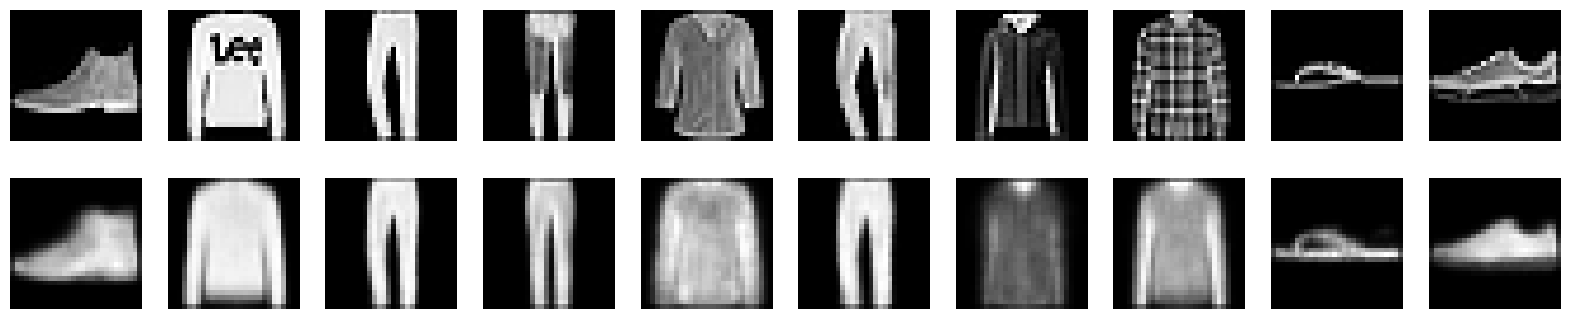

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.datasets import fashion_mnist

(x_train, _), (x_test, _) = fashion_mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

latent_dim = 2
n = 10

encoder_inputs = tf.keras.Input(shape=(28, 28, 1))
x = tf.keras.layers.Conv2D(32, 3, activation='relu', strides=2, padding='same')(encoder_inputs)
x = tf.keras.layers.Conv2D(64, 3, activation='relu', strides=2, padding='same')(x)
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(16, activation='relu')(x)
z_mean = tf.keras.layers.Dense(latent_dim)(x)
z_log_var = tf.keras.layers.Dense(latent_dim)(x)

def sampling(args):
    z_mean, z_log_var = args
    batch = tf.shape(z_mean)[0]
    dim = tf.shape(z_mean)[1]
    epsilon = tf.random.normal(shape=(batch, dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = tf.keras.layers.Lambda(sampling)([z_mean, z_log_var])

encoder = tf.keras.Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')

latent_inputs = tf.keras.Input(shape=(latent_dim,))
x = tf.keras.layers.Dense(7 * 7 * 64, activation='relu')(latent_inputs)
x = tf.keras.layers.Reshape((7, 7, 64))(x)
x = tf.keras.layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(x)
x = tf.keras.layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(x)
decoder_outputs = tf.keras.layers.Conv2DTranspose(1, 3, padding='same', activation='sigmoid')(x)

decoder = tf.keras.Model(latent_inputs, decoder_outputs, name='decoder')

outputs = decoder(z)

class VAELossLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(VAELossLayer, self).__init__(**kwargs)

    def call(self, inputs):
        x, x_decoded, z_mean, z_log_var = inputs

        reconstruction_loss = tf.keras.losses.binary_crossentropy(
            K.flatten(x), K.flatten(x_decoded)
        )
        reconstruction_loss *= 28 * 28

        kl_loss = 1 + z_log_var - K.square(z_mean) - K.exp(z_log_var)
        kl_loss = K.sum(kl_loss, axis=-1)
        kl_loss *= -0.5

        total_loss = K.mean(reconstruction_loss + kl_loss)
        self.add_loss(total_loss)
        return x_decoded

outputs_with_loss = VAELossLayer()([encoder_inputs, outputs, z_mean, z_log_var])

vae = tf.keras.Model(encoder_inputs, outputs_with_loss, name='vae_with_loss')

vae.compile(optimizer='adam')

vae.fit(x_train_cnn, epochs=50, batch_size=256, validation_data=(x_test_cnn, None))

decoded_imgs = vae.predict(x_test_cnn)

plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_cnn[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.show()

# **Variational Autoencoder**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.datasets import fashion_mnist

(x_train, _), (x_test, _) = fashion_mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

latent_dim = 2
n = 10

encoder_inputs = tf.keras.Input(shape=(28, 28, 1))
x = tf.keras.layers.Conv2D(32, 3, activation='relu', strides=2, padding='same')(encoder_inputs)
x = tf.keras.layers.Conv2D(64, 3, activation='relu', strides=2, padding='same')(x)
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(16, activation='relu')(x)
z_mean = tf.keras.layers.Dense(latent_dim)(x)
z_log_var = tf.keras.layers.Dense(latent_dim)(x)

def sampling(args):
    z_mean, z_log_var = args
    batch = tf.shape(z_mean)[0]
    dim = tf.shape(z_mean)[1]
    epsilon = tf.random.normal(shape=(batch, dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = tf.keras.layers.Lambda(sampling)([z_mean, z_log_var])

encoder = tf.keras.Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')

latent_inputs = tf.keras.Input(shape=(latent_dim,))
x = tf.keras.layers.Dense(7 * 7 * 64, activation='relu')(latent_inputs)
x = tf.keras.layers.Reshape((7, 7, 64))(x)
x = tf.keras.layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(x)
x = tf.keras.layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(x)
decoder_outputs = tf.keras.layers.Conv2DTranspose(1, 3, padding='same', activation='sigmoid')(x)

decoder = tf.keras.Model(latent_inputs, decoder_outputs, name='decoder')

outputs = decoder(z)

class VAELossLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(VAELossLayer, self).__init__(**kwargs)

    def call(self, inputs):
        x, x_decoded, z_mean, z_log_var = inputs

        reconstruction_loss = tf.keras.losses.binary_crossentropy(
            K.flatten(x), K.flatten(x_decoded)
        )
        reconstruction_loss *= 28 * 28

        kl_loss = 1 + z_log_var - K.square(z_mean) - K.exp(z_log_var)
        kl_loss = K.sum(kl_loss, axis=-1)
        kl_loss *= -0.5

        total_loss = K.mean(reconstruction_loss + kl_loss)
        self.add_loss(total_loss)
        return x_decoded

outputs_with_loss = VAELossLayer()([encoder_inputs, outputs, z_mean, z_log_var])

vae = tf.keras.Model(encoder_inputs, outputs_with_loss, name='vae_with_loss')

vae.compile(optimizer='adam')

vae.fit(x_train_cnn, epochs=50, batch_size=256, validation_data=(x_test_cnn, None))

decoded_imgs = vae.predict(x_test_cnn)

plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_cnn[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.show()